In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("data\ecommerce_sales_data.csv")

# Show first rows
print(df.head())

<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Aishwarya\AppData\Local\Temp\ipykernel_26596\2111237578.py:4: SyntaxWarning: invalid escape sequence '\e'
  df = pd.read_csv("data\ecommerce_sales_data.csv")


  Order ID Customer ID  Gender  Age Product Category Product Name  Quantity  \
0  ORD0001    CUST9376  Female   43             Home         Lamp         1   
1  ORD0002    CUST3289    Male   57             Toys     Lego Set         5   
2  ORD0003    CUST6409  Female   53         Clothing       Jacket         1   
3  ORD0004    CUST8815  Female   51           Beauty      Perfume         2   
4  ORD0005    CUST1018  Female   39      Electronics   Smartphone         4   

     Price  Order Date    Payment Method       City  Rating  
0  1368.69  07-06-2025  Cash on Delivery  Hyderabad       3  
1   782.44  11-12-2024  Cash on Delivery    Chennai       5  
2  3676.18  05-05-2025       Credit Card  Bangalore       4  
3  4836.37  25-06-2025  Cash on Delivery     Mumbai       5  
4  3580.24  25-12-2024               UPI    Kolkata       3  


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          100 non-null    object 
 1   Customer ID       100 non-null    object 
 2   Gender            100 non-null    object 
 3   Age               100 non-null    int64  
 4   Product Category  100 non-null    object 
 5   Product Name      100 non-null    object 
 6   Quantity          100 non-null    int64  
 7   Price             100 non-null    float64
 8   Order Date        100 non-null    object 
 9   Payment Method    100 non-null    object 
 10  City              100 non-null    object 
 11  Rating            100 non-null    int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 9.5+ KB
None


data cleaning

In [4]:
# Check null values
print(df.isnull().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

print(df.head())

Order ID            0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Product Name        0
Quantity            0
Price               0
Order Date          0
Payment Method      0
City                0
Rating              0
dtype: int64
  Order ID Customer ID  Gender  Age Product Category Product Name  Quantity  \
0  ORD0001    CUST9376  Female   43             Home         Lamp         1   
1  ORD0002    CUST3289    Male   57             Toys     Lego Set         5   
2  ORD0003    CUST6409  Female   53         Clothing       Jacket         1   
3  ORD0004    CUST8815  Female   51           Beauty      Perfume         2   
4  ORD0005    CUST1018  Female   39      Electronics   Smartphone         4   

     Price Order Date    Payment Method       City  Rating  
0  1368.69 2025-06-07  Cash on Delivery  Hyderabad       3  
1   782.44 2024-12-11  Cash on Delivery    Chennai       5  
2  3676.18 2025-05-05       Credit Card  Bangalore       4  
3  4

Create Total Sales Column

In [5]:
df['Total Sales'] = df['Quantity'] * df['Price']

print(df[['Quantity', 'Price', 'Total Sales']].head())

   Quantity    Price  Total Sales
0         1  1368.69      1368.69
1         5   782.44      3912.20
2         1  3676.18      3676.18
3         2  4836.37      9672.74
4         4  3580.24     14320.96


Total Revenue

In [6]:
total_revenue = df['Total Sales'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 694219.8699999999


Average Rating

In [7]:
avg_rating = df['Rating'].mean()

print("Average Rating:", avg_rating)

Average Rating: 3.0


Top Product Categories

In [8]:
top_categories = df.groupby('Product Category')['Total Sales'].sum()

print(top_categories)

Product Category
Beauty          84457.92
Books          129177.30
Clothing       121504.99
Electronics    140811.26
Home           136365.47
Toys            81902.93
Name: Total Sales, dtype: float64


Best Selling Products

In [9]:

best_products = df.groupby('Product Name')['Quantity'].sum()

print(best_products.sort_values(ascending=False))

Product Name
Smartphone       25
Curtains         25
Comics           23
Fiction          20
Smartwatch       19
T-Shirt          18
Perfume          17
Dress            16
Lego Set         16
Lamp             16
Biography        15
Action Figure    14
Jeans            14
Cookware Set     10
Lipstick         10
Face Cream        8
Jacket            8
Headphones        7
Laptop            7
Puzzle            6
Name: Quantity, dtype: int64


City-wise Sales

In [10]:
city_sales = df.groupby('City')['Total Sales'].sum()

print(city_sales)

City
Bangalore     90184.49
Chennai      109181.81
Delhi         55782.47
Hyderabad    130424.17
Kolkata      190462.98
Mumbai       118183.95
Name: Total Sales, dtype: float64


Data Visualization

import matplotlib.pyplot as plt

In [11]:
import matplotlib.pyplot as plt

Category Sales Bar Chart

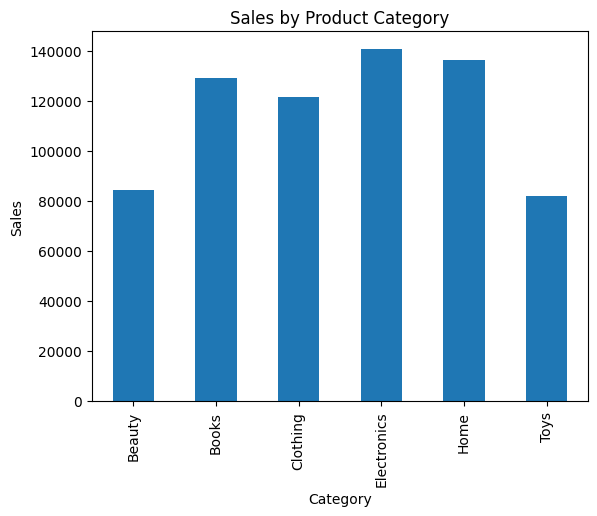

In [12]:
top_categories.plot(kind='bar')

plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

Payment Method Pie Chart

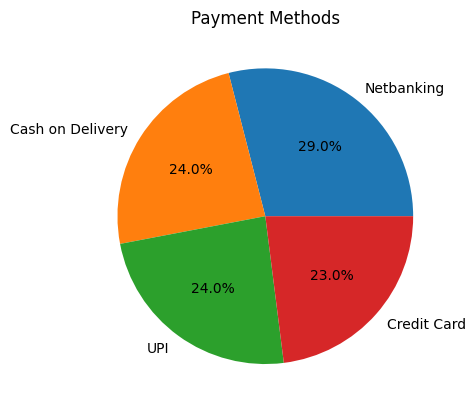

In [13]:
payment_data = df['Payment Method'].value_counts()

payment_data.plot(kind='pie', autopct='%1.1f%%')

plt.title("Payment Methods")

plt.ylabel("")

plt.show()

Monthly Sales Trend

In [14]:
df['Month'] = df['Order Date'].dt.month

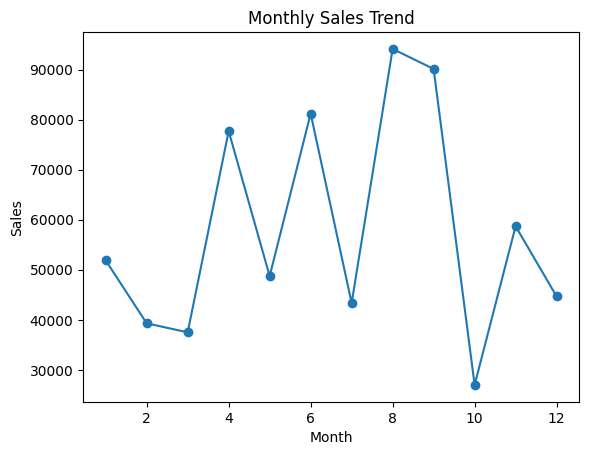

In [15]:
monthly_sales = df.groupby('Month')['Total Sales'].sum()

monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()